In [1]:
%reload_ext autoreload
%autoreload 2

import os
from tqdm import tqdm
import gc

import numpy as np
import pickle
import jax
from jax import jit, vmap
import jax.numpy as jnp

from fpp.utils.cart import to_cart
from fpp.models.np_model import NPModel

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
mpl.rc_file('matplotlibrc')

In [2]:
npmodel = NPModel()

samples = pickle.load(open('../outputs/production/fits/fermi/hmc-seed42.p', 'rb'))
samples.keys()

No data provided. Using Fermi data.


dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'C', 'S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_bulge_poiss', 'theta_bulge_ps', 'theta_ics', 'theta_pib', 'zs'])

In [3]:
def get_mask(extent=10, pixelsize=0.1, mask_b=2): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    mask_plane_cart = np.zeros((npixels, npixels), dtype=np.int32)
    i_mask_b_fm = int((extent - mask_b) / pixelsize)
    i_mask_b_to = int((extent + mask_b) / pixelsize)
    mask_plane_cart[i_mask_b_fm:i_mask_b_to] = 1
    return np.array(mask_plane_cart, dtype=bool)

mask = get_mask()

def get_t_med_var(ts, extent=10, pixelsize=0.1): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    t_med = jnp.median(ts, axis=0)
    t_var = jnp.quantile(ts, 0.84, axis=0) - jnp.quantile(ts, 0.16, axis=0)
    t_med_cart = to_cart(np.array(t_med), n_pixels=npixels, pixelsize=pixelsize)
    t_var_cart = to_cart(np.array(t_var), n_pixels=npixels, pixelsize=pixelsize)
    
    return t_med_cart, t_var_cart

def get_cart_from_hp(m, extent=10, pixelsize=0.1): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    return to_cart(np.array(m), n_pixels=npixels, pixelsize=pixelsize)

## Load bulge templates (seperately)

In [5]:
from fpp.models.bulge_models import BulgeTemplates
from fpp.models.templates import NFWTemplate, LorimerDiskTemplate

In [6]:
nside = 128
bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']
bulge_templates = np.array([
    BulgeTemplates(template_name=n, nside_out=nside)()
    for n in bulge_names
])
nfw_template = NFWTemplate(nside=nside)
disk_template = LorimerDiskTemplate(nside=nside)

## Visualize bulges

In [7]:
extent = 10 # [deg]
pixelsize = 0.1
npixels = int(2 * extent / pixelsize)
mask_b = 2 # [deg]

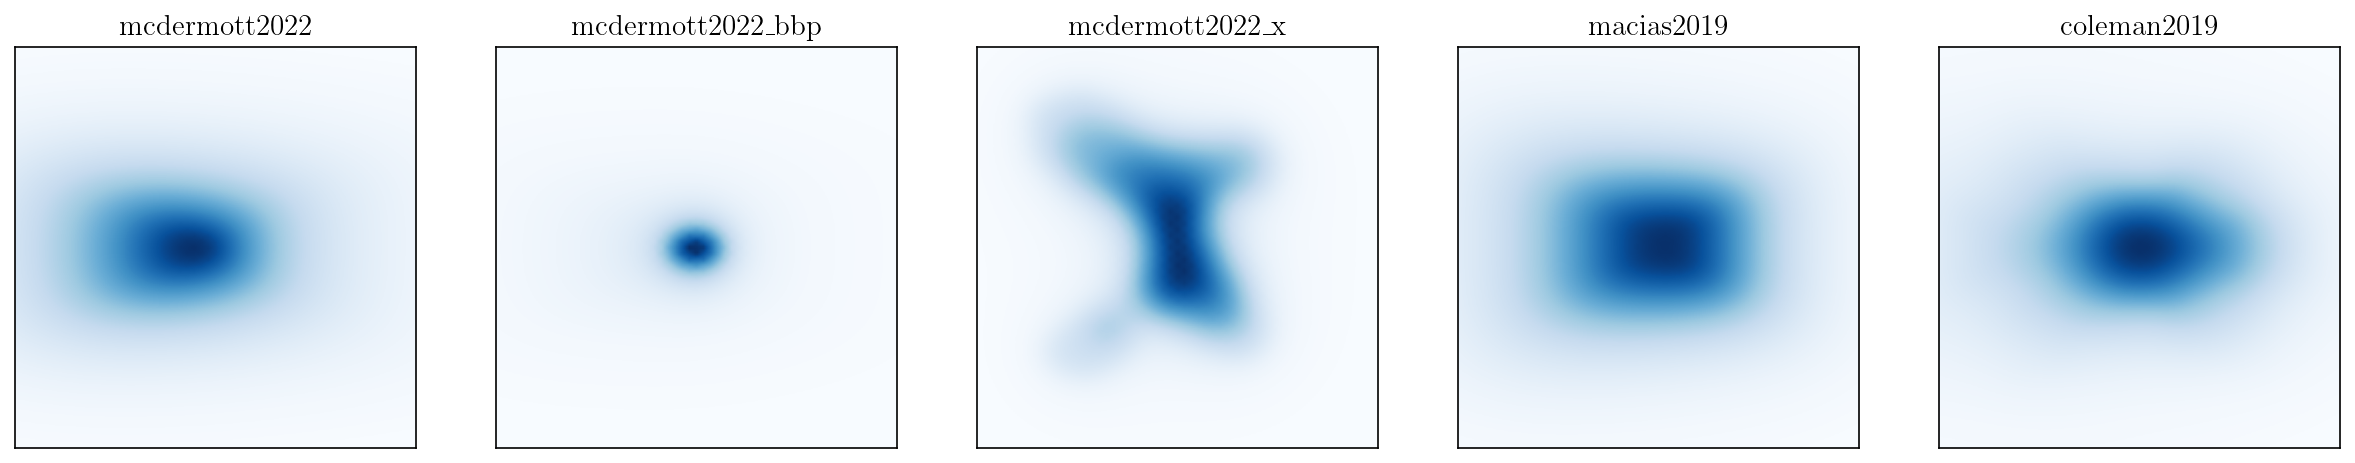

In [9]:
bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axs[i].imshow(
        to_cart(np.array(npmodel.blg_s[i]), n_pixels=npixels, pixelsize=pixelsize),
        cmap='Blues'
    )
    axs[i].set(title=bulge_names[i], xticks=[], yticks=[])

## Get templates median & variation

In [5]:
t_dict = {}

In [ ]:
t_dict = pickle.load(open('../outputs/production/gce_shape_data.p', 'rb'))


In [7]:
name = 'dsk'
n_plot = 1000

def get_dsk_templates(S, zs, C):
    temp = npmodel.dsk_temp_gen.get_template(zs=zs, C=C)
    temp = temp / np.mean(temp[~npmodel.nm])
    return S * temp

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_dsk_templates(samples['Sps_dsk'][i], samples['zs'][i], samples['C'][i]))
ts = np.array(ts)
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:05<00:00, 170.01it/s]


0

In [37]:
f = samples['Sps_gce'] / (samples['Sps_gce'] + samples['S_gce'])

(array([0.01961901, 0.02697614, 0.03923802, 0.06376179, 0.13855926,
        0.14346402, 0.20232105, 0.24401145, 0.27221378, 0.36785645,
        0.46349913, 0.53339186, 0.59592746, 0.68543919, 0.73326053,
        0.84852222, 0.91228401, 0.93680777, 1.03245045, 1.13299788,
        1.24335482, 1.44690206, 1.52292572, 1.69581826, 1.93369876,
        2.18016259, 2.71723301, 3.47011256, 4.64480084, 6.53803539]),
 array([0.18445811, 0.21164262, 0.23882714, 0.26601166, 0.29319618,
        0.32038069, 0.34756521, 0.37474973, 0.40193424, 0.42911876,
        0.45630328, 0.48348779, 0.51067231, 0.53785683, 0.56504134,
        0.59222586, 0.61941038, 0.64659489, 0.67377941, 0.70096393,
        0.72814845, 0.75533296, 0.78251748, 0.809702  , 0.83688651,
        0.86407103, 0.89125555, 0.91844006, 0.94562458, 0.9728091 ,
        0.99999361]),
 <BarContainer object of 30 artists>)

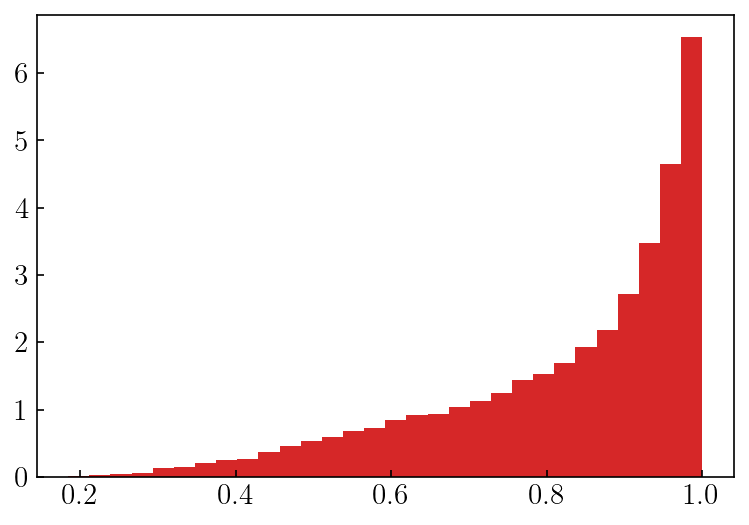

In [ ]:
plt.hist(f, bins=30, density=True);

In [43]:
print(np.median(f), np.quantile(f, 0.025), np.quantile(f, 0.975))

0.8795445766432589 0.406121151230394 0.9963901508846801


In [30]:
from fpp.utils.create_mask import make_ring_mask

In [31]:
mask = make_ring_mask(0, 10, 0, 0, 128)

In [34]:
np.sum(~mask & ~npmodel.nm)

1136

In [ ]:
def get_nfw_templates(S, gamma):
    temp = npmodel.nfw_temp_gen.get_NFW2_template(gamma=gamma)
    temp = temp / np.mean(temp[~npmodel.nm])
    return S * temp
def get_blg_templates(S, theta):
    return S * jnp.dot(theta, npmodel.blg_s)
def get_gce_templates(S_gce, f_bulge, gamma, theta):
    return get_nfw_templates(S_gce*(1-f_bulge), gamma) + get_blg_templates(S_gce*f_bulge, theta)

name = 'gce_ps'
n_plot = 5
ts = []
ts_nfw = []
ts_blg = []
for i in tqdm(range(500, 505)):
    ts.append(get_gce_templates(
        samples['Sps_gce'][i],
        samples['f_bulge_ps'][i],
        samples['gamma_ps'][i],
        samples['theta_bulge_ps'][i]
    ))
    print('tot:', np.mean(ts[-1][~npmodel.nm]))
    print('tot 10:', np.mean(ts[-1][~mask & ~npmodel.nm]))
    ts_nfw.append(get_nfw_templates(
        samples['Sps_gce'][i] * (1-samples['f_bulge_ps'][i]),
        samples['gamma_ps'][i]
    ))
    print('NFW:', np.mean(ts_nfw[-1][~npmodel.nm]))
    print('NFW 10:', np.mean(ts_nfw[-1][~mask & ~npmodel.nm]))
    ts_blg.append(get_blg_templates(
        samples['Sps_gce'][i] * samples['f_bulge_ps'][i],
        samples['theta_bulge_ps'][i]
    ))
    print('BLG:', np.mean(ts_blg[-1][~npmodel.nm]))
    print('BLG 10:', np.mean(ts_blg[-1][~mask & ~npmodel.nm]))
    print()
ts = np.array(ts)
ts_nfw = np.array(ts_nfw)
ts_blg = np.array(ts_blg)

In [29]:
to_cart(np.array(ts_nfw[-1])).shape

(96, 96)

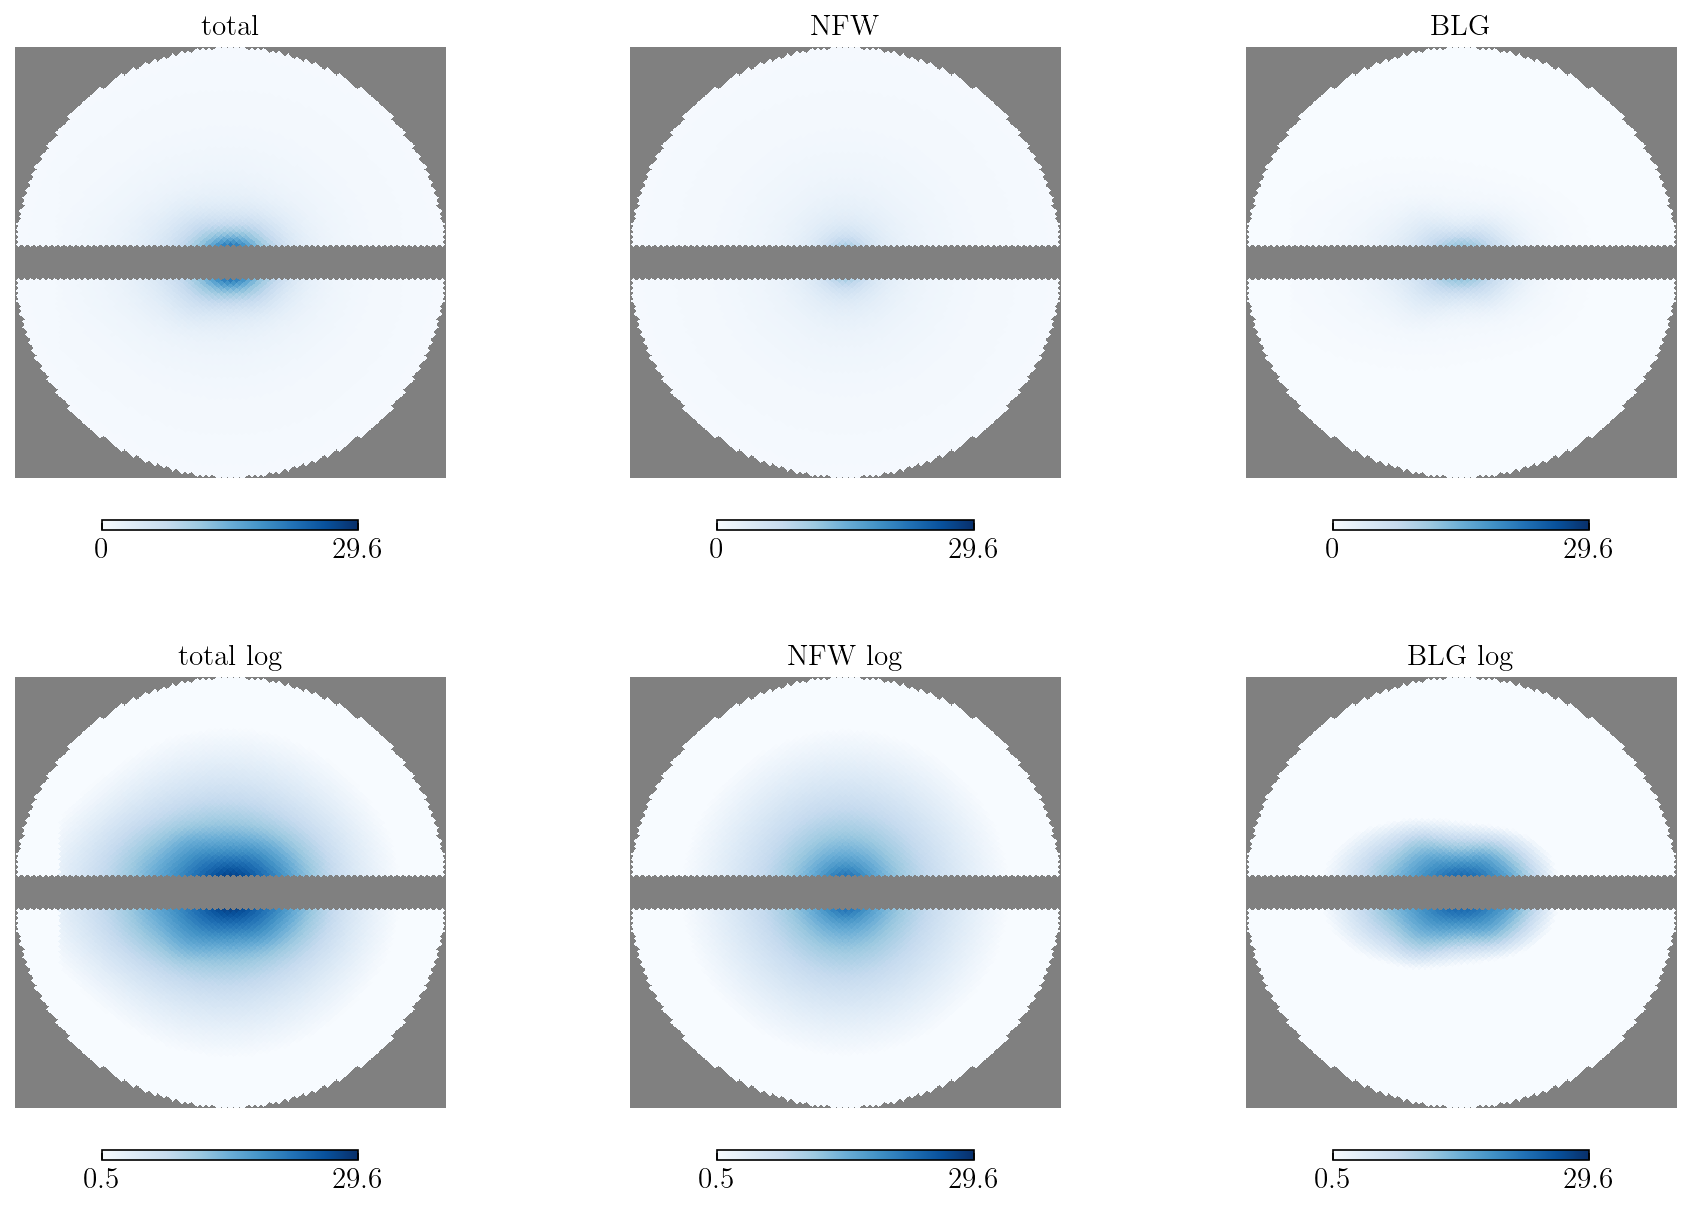

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.sca(axs[0, 0])
t = np.array(ts_nfw[-1] + ts_blg[-1])
t[npmodel.nm] = np.nan
hp.cartview(t, cmap='Blues', lonra=[-25, 25], latra=[-25, 25], hold=True, min=0, max=vmax, title='total')
plt.sca(axs[0, 1])
t = np.array(ts_nfw[-1])
t[npmodel.nm] = np.nan
hp.cartview(t, cmap='Blues', lonra=[-25, 25], latra=[-25, 25], hold=True, min=0, max=vmax, title='NFW')
plt.sca(axs[0, 2])
t = np.array(ts_blg[-1])
t[npmodel.nm] = np.nan
hp.cartview(t, cmap='Blues', lonra=[-25, 25], latra=[-25, 25], hold=True, min=0, max=vmax, title='BLG')

plt.sca(axs[1, 0])
t = np.array(ts_nfw[-1] + ts_blg[-1])
t[npmodel.nm] = np.nan
hp.cartview(np.clip(t, 0.5, None), cmap='Blues', lonra=[-25, 25], latra=[-25, 25], hold=True, min=0.5, max=vmax, norm='log', title='total log')
plt.sca(axs[1, 1])
t = np.array(ts_nfw[-1])
t[npmodel.nm] = np.nan
hp.cartview(np.clip(t, 0.5, None), cmap='Blues', lonra=[-25, 25], latra=[-25, 25], hold=True, min=0.5, max=vmax, norm='log', title='NFW log')
plt.sca(axs[1, 2])
t = np.array(ts_blg[-1])
t[npmodel.nm] = np.nan
hp.cartview(np.clip(t, 0.5, None), cmap='Blues', lonra=[-25, 25], latra=[-25, 25], hold=True, min=0.5, max=vmax, norm='log', title='BLG log')

In [12]:
import healpy as hp

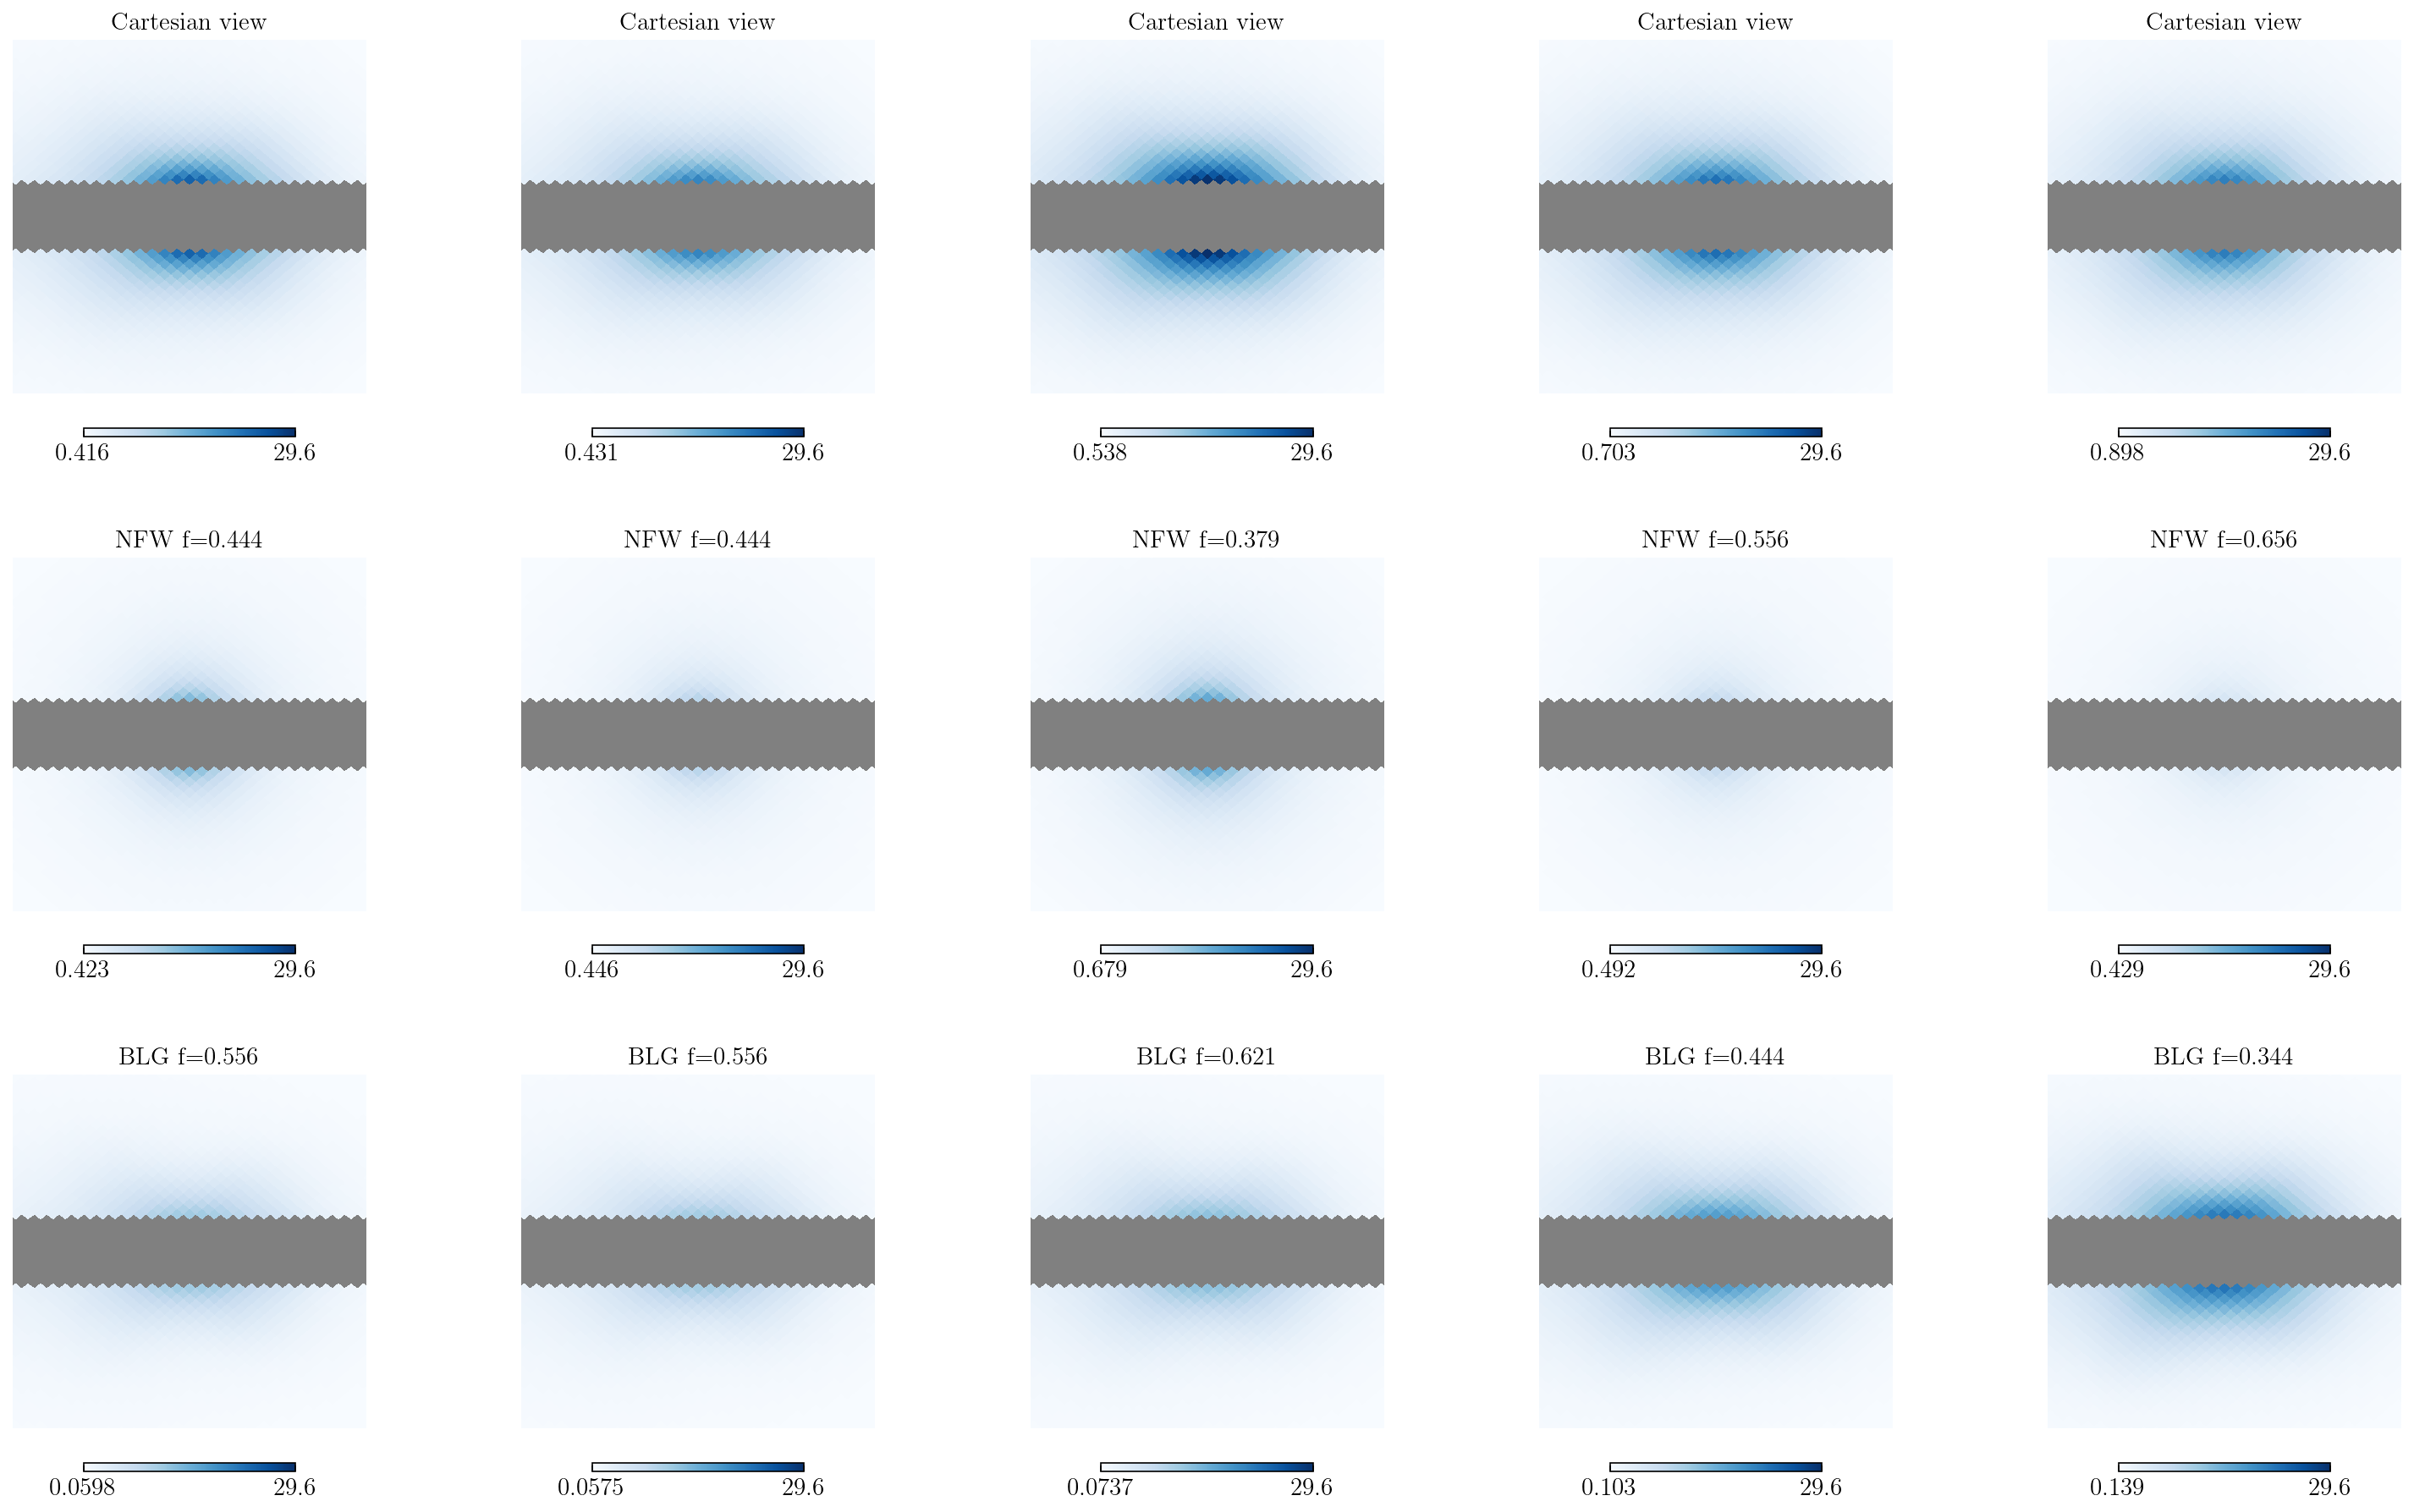

In [19]:
fig, axs = plt.subplots(3, 5, figsize=(25, 15))

vmax = np.max(ts[:5, ~npmodel.nm])
ts[:, npmodel.nm] = np.nan
ts_nfw[:, npmodel.nm] = np.nan
ts_blg[:, npmodel.nm] = np.nan

for i in range(5):
    plt.sca(axs[0, i])
    hp.cartview(ts[i], cmap='Blues', lonra=[-10, 10], latra=[-10, 10], hold=True, min=0, max=vmax)
    plt.sca(axs[1, i])
    hp.cartview(ts_nfw[i], cmap='Blues', lonra=[-10, 10], latra=[-10, 10], hold=True, min=0, max=vmax, title=f"NFW f={(1-samples['f_bulge_ps'][i]):.3f}")
    plt.sca(axs[2, i])
    hp.cartview(ts_blg[i], cmap='Blues', lonra=[-10, 10], latra=[-10, 10], hold=True, min=0, max=vmax, title=f"BLG f={samples['f_bulge_ps'][i]:.3f}")

In [9]:
name = 'gce_ps'
n_plot = 1000

def get_nfw_templates(S, gamma):
    temp = npmodel.nfw_temp_gen.get_NFW2_template(gamma=gamma)
    temp = temp / np.mean(temp[~npmodel.nm])
    return S * temp
def get_blg_templates(S, theta):
    return S * jnp.dot(theta, npmodel.blg_s)
def get_gce_templates(S_gce, f_bulge, gamma, theta):
    return get_nfw_templates(S_gce*(1-f_bulge), gamma) + get_blg_templates(S_gce*f_bulge, theta)

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_gce_templates(
        samples['Sps_gce'][i],
        samples['f_bulge_ps'][i],
        samples['gamma_ps'][i],
        samples['theta_bulge_ps'][i]
    ))
ts = np.array(ts)

t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:09<00:00, 106.52it/s]


0

In [10]:
name = 'gce_poiss'
n_plot = 1000

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_gce_templates(
        samples['S_gce'][i],
        samples['f_bulge_poiss'][i],
        samples['gamma_poiss'][i],
        samples['theta_bulge_poiss'][i]
    ))
ts = np.array(ts)

t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:07<00:00, 133.38it/s]


0

In [11]:
name = 'blg_ps'
n_plot = 1000

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_blg_templates(
        samples['Sps_gce'][i] * samples['f_bulge_ps'][i],
        samples['theta_bulge_ps'][i]
    ))
ts = np.array(ts)
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

100%|██████████| 1000/1000 [00:03<00:00, 252.64it/s]


0

In [12]:
name = 'blg_poiss'
n_plot = 1000

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_blg_templates(
        samples['S_gce'][i] * samples['f_bulge_poiss'][i],
        samples['theta_bulge_poiss'][i]
    ))
ts = np.array(ts)
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

  3%|▎         | 26/1000 [00:00<00:03, 258.55it/s]

100%|██████████| 1000/1000 [00:03<00:00, 259.62it/s]


0

In [13]:
print(t_dict.keys())
pickle.dump(t_dict, open('../outputs/production/gce_shape_data.p', 'wb'))

dict_keys(['dsk_med', 'dsk_var', 'gce_ps_med', 'gce_ps_var', 'gce_poiss_med', 'gce_poiss_var', 'blg_ps_med', 'blg_ps_var', 'blg_poiss_med', 'blg_poiss_var', 'gamma_ps_best_fit', 'gamma_poiss_best_fit'])


# gamma best fits

In [4]:
from scipy.optimize import curve_fit

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def find_peak_value(data, n_bins=50, plot=False):

    counts, bin_edges = np.histogram(data, bins=n_bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    i_max = np.argmax(counts)
    p0 = [counts[i_max], bin_centers[i_max], np.std(data)]

    popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0)
    amp_fit, mu_fit, sigma_fit = popt

    if plot:
        x_fine = np.linspace(bin_edges[0], bin_edges[-1], 300)
        y_fine = gaussian(x_fine, *popt)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(data, bins=n_bins, alpha=0.6, color="steelblue", edgecolor="white", label="Data")
        ax.plot(x_fine, y_fine, "r-", lw=2, label=f"Gaussian fit\n$\\mu={mu_fit:.3f}$, $\\sigma={abs(sigma_fit):.3f}$")
        ax.axvline(mu_fit, color="r", ls="--", lw=1, alpha=0.7, label=f"Peak at {mu_fit:.3f}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")
        ax.legend()
        ax.set_title("Gaussian Fit to Histogram")
        plt.tight_layout()
        plt.show()

    return mu_fit

In [7]:
t_dict['gamma_ps_best_fit'] = find_peak_value(samples['gamma_ps'])
t_dict['gamma_poiss_best_fit'] = find_peak_value(samples['gamma_poiss'])
print(t_dict['gamma_ps_best_fit'], np.median(samples['gamma_ps']))
print(t_dict['gamma_poiss_best_fit'], np.median(samples['gamma_poiss']))

0.9747298578809008 0.9808585879696256
0.6791818886038776 0.7787779256692083


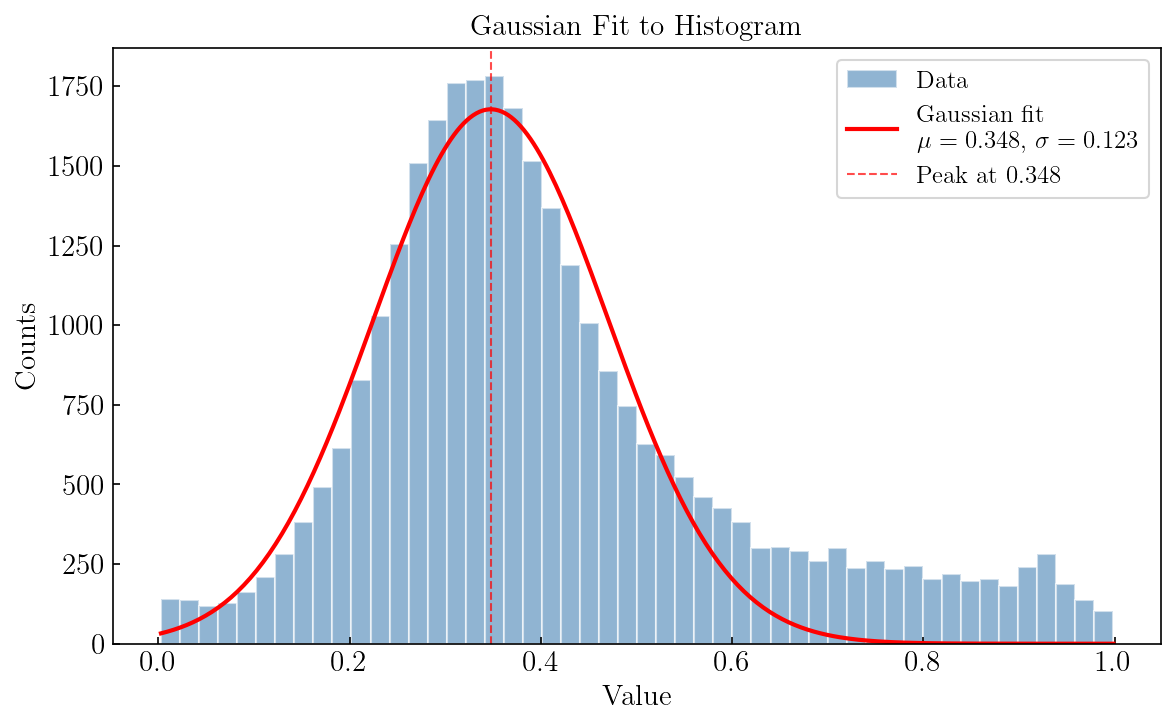

0.3477106311795914

In [10]:
find_peak_value(samples['f_bulge_ps'], n_bins=50, plot=True)

(array([2619., 2334., 2029., 1691., 1571., 1389., 1224., 1122.,  993.,
         937.,  808.,  761.,  662.,  636.,  622.,  509.,  527.,  484.,
         449.,  429.,  418.,  382.,  371.,  342.,  350.,  344.,  326.,
         343.,  342.,  278.,  280.,  246.,  242.,  243.,  249.,  285.,
         271.,  246.,  239.,  232.,  223.,  206.,  217.,  214.,  189.,
         216.,  214.,  246.,  219.,  231.]),
 array([2.68936656e-05, 2.00214249e-02, 4.00159561e-02, 6.00104874e-02,
        8.00050186e-02, 9.99995498e-02, 1.19994081e-01, 1.39988612e-01,
        1.59983144e-01, 1.79977675e-01, 1.99972206e-01, 2.19966737e-01,
        2.39961268e-01, 2.59955800e-01, 2.79950331e-01, 2.99944862e-01,
        3.19939393e-01, 3.39933925e-01, 3.59928456e-01, 3.79922987e-01,
        3.99917518e-01, 4.19912050e-01, 4.39906581e-01, 4.59901112e-01,
        4.79895643e-01, 4.99890174e-01, 5.19884706e-01, 5.39879237e-01,
        5.59873768e-01, 5.79868299e-01, 5.99862831e-01, 6.19857362e-01,
        6.39851893e-01, 

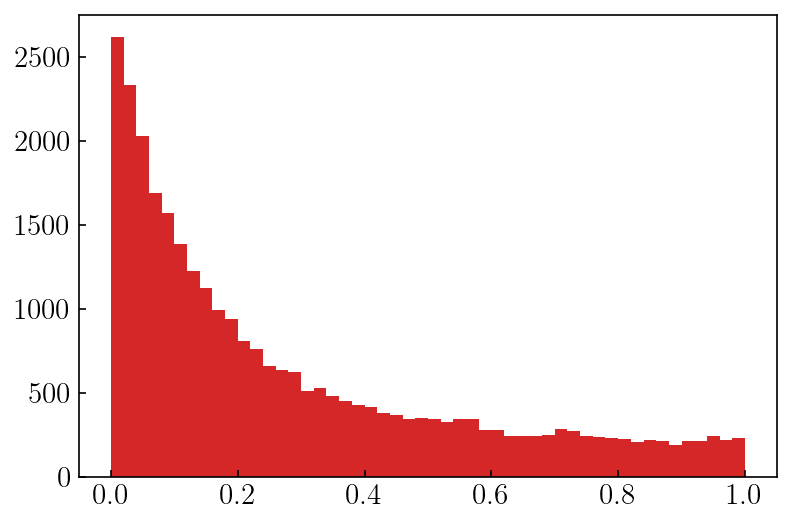

In [12]:
plt.hist(samples['f_bulge_poiss'], bins=50)

# plot

In [4]:
t_dict = pickle.load(open('../outputs/production/gce_shape_data.p', 'rb'))

/tmp/ipykernel_2542310/1437360220.py:114: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.01)


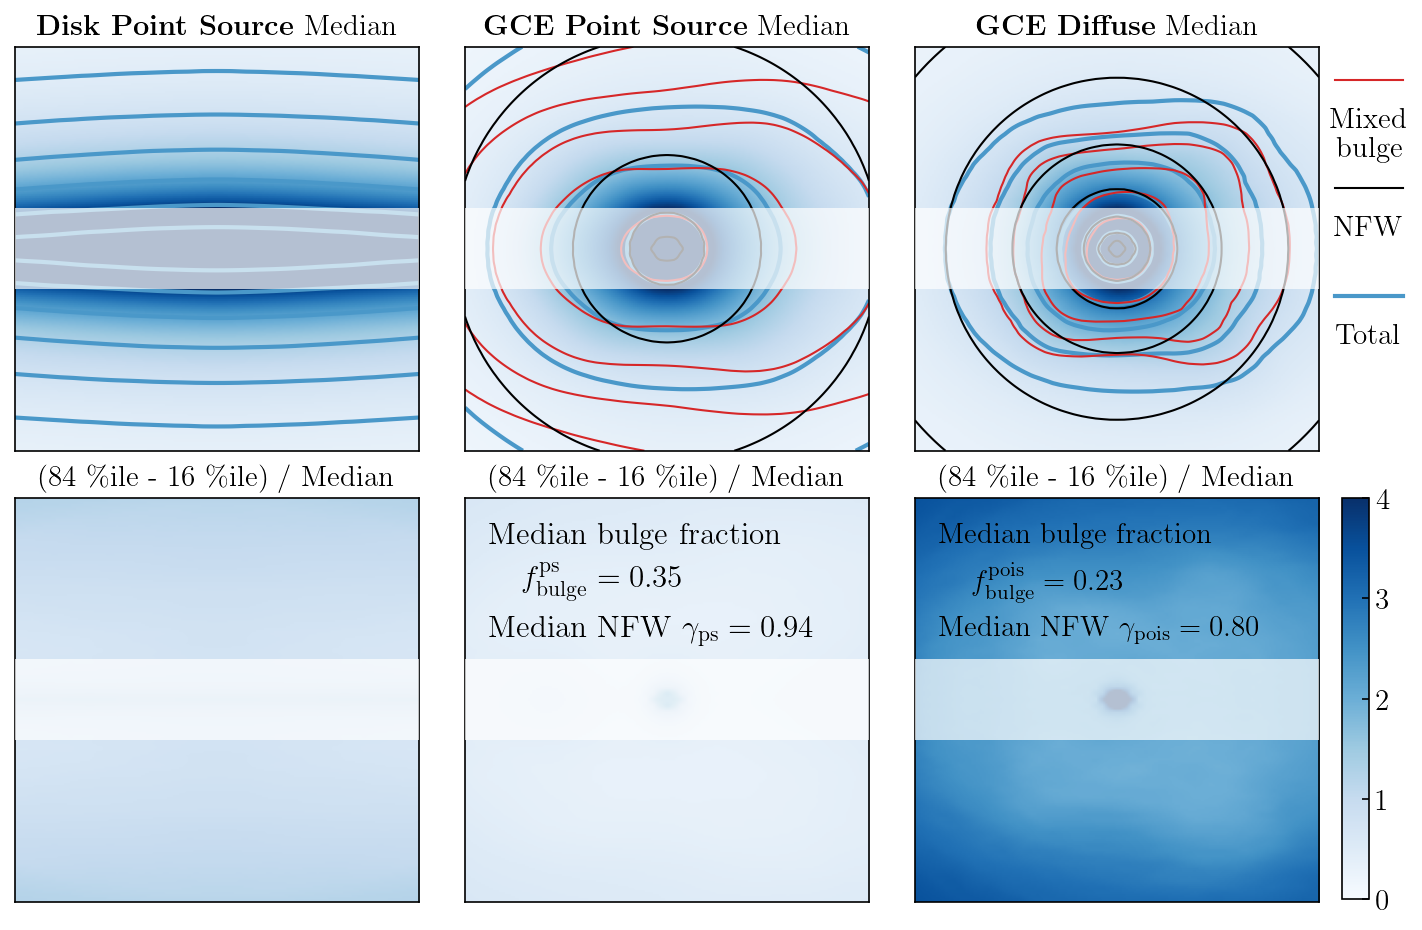

In [9]:
bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']

options = {
    'dsk'       : dict(plot_bulge=None, plot_nfw=False, n_level=10, title=r'$\textbf{Disk Point Source}$', vmin=0.1),
    'gce_ps'    : dict(plot_bulge='blg_ps_med', plot_nfw=True, n_level=6, title=r'$\textbf{GCE Point Source}$', vmin=0.5),
    'gce_poiss' : dict(plot_bulge='blg_poiss_med', plot_nfw=True, n_level=7, title=r'$\textbf{GCE Diffuse}$', vmin=0.5),
}

n_plot = len(options.items())
extent = 10
mask_b = 2
plot_extent = (-extent, extent, extent, -extent)

# main_cmap = mpl.colors.LinearSegmentedColormap.from_list("white_to_C0", ["white", 'C0'])
main_cmap = mpl.colormaps.get_cmap('Blues')

color_bulge = 'C0'
color_nfw = 'k'
color_total = main_cmap(0.6)

fig, axs = plt.subplots(2, n_plot, figsize=(3*n_plot, 6), layout='constrained')

for i, (name, option) in enumerate(options.items()):

    t_med = np.array(t_dict[name+'_med'])
    t_var = np.array(t_dict[name+'_var'])
    
    vmax_masked = np.max(t_med[~mask])
    vmax = np.max(t_med)
    levels = np.geomspace(option['vmin'], vmax, option['n_level'])
    
    axs[0,i].imshow(np.flip(t_med), vmax=vmax_masked, vmin=0, cmap=main_cmap, extent=plot_extent)
    cs = axs[0,i].contour(np.flip(t_med), colors=mpl.colors.to_hex(color_total, keep_alpha=True),
                          levels=levels, extent=plot_extent, linewidths=2)
    
    have_legend = False
    if option['plot_bulge'] is not None:
        have_legend = True
        plot_one_bulge = False
        if plot_one_bulge:
            i_blg = bulge_names.index(option['plot_bulge'])
            t_blg = get_cart_from_hp(npmodel.bulge_templates[i_blg]) # plot one bulge
        else:
            t_blg = t_dict[option['plot_bulge']] # plot average bulge 
        vmax_masked_blg = np.max(t_blg[~mask])
        t_blg *= vmax_masked / vmax_masked_blg
        vmax_blg = np.max(t_blg)
        cs1 = axs[0,i].contour(np.flip(t_blg), colors=color_bulge, levels=levels,
                         linestyles='-', extent=plot_extent, linewidths=1.0)
        h1, _ = cs1.legend_elements()
        
    if option['plot_nfw']:
        have_legend = True
        if 'ps' in name:
            # gamma_best_fit = t_dict['gamma_ps_best_fit']
            gamma_best_fit = np.median(samples['gamma_ps'])
        else:
            # gamma_best_fit = t_dict['gamma_poiss_best_fit']
            gamma_best_fit = np.median(samples['gamma_poiss'])
        t_nfw = get_cart_from_hp(npmodel.nfw_temp_gen.get_NFW2_template(gamma=gamma_best_fit))
        vmax_masked_nfw = np.max(t_nfw[~mask])
        t_nfw *= vmax_masked / vmax_masked_nfw
        vmax_nfw = np.max(t_nfw)
        cs2 = axs[0,i].contour(np.flip(t_nfw), colors=color_nfw, levels=levels,
                         linestyles='-', extent=plot_extent, linewidths=1.0)
        h2, _ = cs2.legend_elements()
        
    # if have_legend:
    #     axs[0,i].legend([h1[0], h2[0]], ['Mixed bulge', f'NFW $\gamma={gamma_best_fit:.2f}$'], fontsize=10)
    
    axs[0,i].fill_between([-extent, extent], [-mask_b, -mask_b], [+mask_b, +mask_b], color='white', alpha=0.7, ec='none', zorder=10)
    axs[1,i].fill_between([-extent, extent], [-mask_b, -mask_b], [+mask_b, +mask_b], color='white', alpha=0.7, ec='none', zorder=10)
    
    im = axs[1,i].imshow(np.flip(t_var)/np.flip(t_med), vmax=4, vmin=0, cmap=main_cmap, extent=plot_extent)
    axs[0,i].set(xticks=[], yticks=[], title=option['title']+' Median')
    axs[1,i].set(xticks=[], yticks=[], title='(84 \%ile - 16 \%ile) / Median')
    
cax = fig.add_axes([1.0, 0.0095, 0.02, 0.446])
fig.colorbar(axs[1, 2].images[0], cax=cax, aspect=40)

# Add legend
line_len = 0.025  # half-length of each line

entries = [
    {"color": color_bulge, "label": "Mixed\nbulge", "x": 1.02, "y": 0.92, 'lw': 1},
    {"color": color_nfw,   "label": "NFW",          "x": 1.02, "y": 0.80, 'lw': 1},
    {"color": color_total,   "label": "Total",       "x": 1.02, "y": 0.68, 'lw': 2},
]
for e in entries:
    # Draw dotted line
    fig.lines.append(mpl.lines.Line2D(
        [e["x"] - line_len, e["x"] + line_len],
        [e["y"], e["y"]],
        ls="-", color=e["color"], linewidth=1.0, lw=e["lw"],
        transform=fig.transFigure, figure=fig
    ))
    # Text below the line
    fig.text(
        e["x"], e["y"] - 0.03, e["label"],
        ha="center", va="top", fontsize=14,
        transform=fig.transFigure
    )

text_kwargs = dict(ha='left', va='top', transform=axs[1, 1].transAxes, fontsize=15)
axs[1, 1].text(0.06, 0.94, r'Median bulge fraction', **text_kwargs)
axs[1, 1].text(0.14, 0.84, r'$f_\mathrm{bulge}^\mathrm{ps}=' + f'{np.median(samples["f_bulge_ps"]):.2f}$', **text_kwargs)
axs[1, 1].text(0.06, 0.71, r'Median NFW $\gamma_\mathrm{ps}=' + f'{np.median(samples["gamma_ps"]):.2f}$', **text_kwargs)

text_kwargs = dict(ha='left', va='top', transform=axs[1, 2].transAxes, fontsize=14)
axs[1, 2].text(0.06, 0.94, r'Median bulge fraction', **text_kwargs)
axs[1, 2].text(0.14, 0.84, r'$f_\mathrm{bulge}^\mathrm{pois}=' + f'{np.median(samples["f_bulge_poiss"]):.2f}$', **text_kwargs)
axs[1, 2].text(0.06, 0.71, r'Median NFW $\gamma_\mathrm{pois}=' + f'{np.median(samples["gamma_poiss"]):.2f}$', **text_kwargs)

fig.subplots_adjust(wspace=0.01)
fig.savefig('../outputs/production/plots/gce-shape.pdf', dpi=300)